No GPU available, using CPU.
Found 1548 files belonging to 3 classes.
Found 388 files belonging to 3 classes.
Found 216 files belonging to 3 classes.
Epoch 1/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 6s/step - accuracy: 0.5537 - loss: 45.0984 - val_accuracy: 0.9278 - val_loss: 1.7172
Epoch 2/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 97s 6s/step - accuracy: 0.9297 - loss: 2.3888 - val_accuracy: 0.8969 - val_loss: 1.5474
Epoch 3/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9484 - loss: 0.5449 - val_accuracy: 0.9613 - val_loss: 0.3794
Epoch 4/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9800 - loss: 0.1044 - val_accuracy: 0.9536 - val_loss: 0.2701
Epoch 5/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9687 - loss: 0.1433 - val_accuracy: 0.9485 - val_loss: 0.2727
Epoch 6/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9814 - loss: 0.0447 - val_accuracy: 0.9665 - val_loss: 0.1992
Epoch 7/40
16/16 ━━━━━━━━━━━━━━━━━━━━ 96s 6s/step - accuracy: 0.9831 - loss: 0.0330 - val_acc

Training time: 5814.51 seconds
Model saved to vgg19_model.h5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 933ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.97      0.98      0.98       100
     Class 1       0.96      0.97      0.97       100
     Class 2       1.00      0.88      0.93        16

    accuracy                           0.97       216
   macro avg       0.98      0.94      0.96       216
weighted avg       0.97      0.97      0.97       216

Accuracy: 96.76%


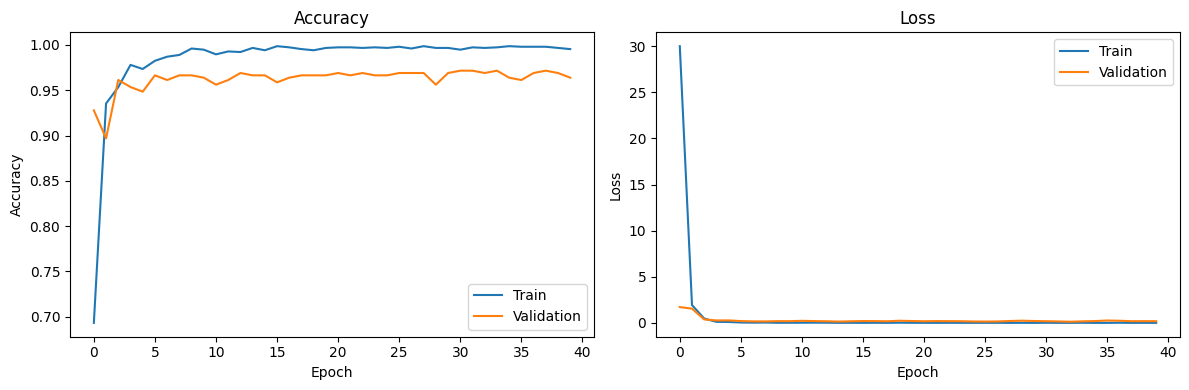

In [5]:
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Dropout
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.applications import VGG19
import time
import pickle

# Constants
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 100
EPOCHS = 40  # Reduce the number of epochs for quicker experimentation
dataset_dir = "./dataset"
testing_dir = "./testing"
validation_dir = "./validation"
training_dir = "./training"

# Check if GPU is available and set memory growth
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(f'{len(gpus)} Physical GPUs, {len(logical_gpus)} Logical GPUs')
    except RuntimeError as e:
        print(e)
else:
    print('No GPU available, using CPU.')

# Function to configure datasets for performance
def configure_for_performance(ds):
    ds = ds.cache()
    ds = ds.shuffle(buffer_size=1000)
    ds = ds.prefetch(buffer_size=tf.data.experimental.AUTOTUNE)
    return ds

# Load the augmented training dataset
augmented_dataset = tf.keras.utils.image_dataset_from_directory(
    training_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE,
    seed=123,
    validation_split=None  # Remove validation_split
)
augmented_dataset = configure_for_performance(augmented_dataset)

# Load the validation dataset
validation_fold_ds = tf.keras.utils.image_dataset_from_directory(
    validation_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE
)
validation_fold_ds = configure_for_performance(validation_fold_ds)

# Load the testing dataset
test_fold_ds = tf.keras.utils.image_dataset_from_directory(
    testing_dir,
    image_size=(IMAGE_SIZE[0], IMAGE_SIZE[1]),
    batch_size=BATCH_SIZE
)
test_fold_ds = configure_for_performance(test_fold_ds)

# Function to create a VGG19 model
def create_vgg19_model(input_shape, num_classes):
    base_model = VGG19(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False  # Freeze the base model
    
    model = Sequential([
        base_model,
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])
    
    return model

# Function to calculate and print metrics
def calculate_metrics(model, test_dataset, num_classes):
    true_labels = []
    predicted_labels = []

    for images, labels in test_dataset:
        true_labels.extend(labels.numpy())
        predictions = model.predict(images)
        predicted_labels.extend(np.argmax(predictions, axis=1))

    true_labels = np.array(true_labels)
    predicted_labels = np.array(predicted_labels)

    # Print classification report
    print("Classification Report:")
    print(classification_report(true_labels, predicted_labels, target_names=[f"Class {i}" for i in range(num_classes)]))

    # Print accuracy
    accuracy = accuracy_score(true_labels, predicted_labels)
    print(f"Accuracy: {accuracy * 100:.2f}%")

# Create a VGG19 model
input_shape = (IMAGE_SIZE[0], IMAGE_SIZE[1], 3)
vgg19_model = create_vgg19_model(input_shape, num_classes=3)

vgg19_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model and calculate training time
start_time = time.time()

history = vgg19_model.fit(
    augmented_dataset,
    epochs=EPOCHS,
    validation_data=validation_fold_ds,
)

end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Save the history
history_path = 'training_history.pkl'
with open(history_path, 'wb') as f:
    pickle.dump(history.history, f)

# Optionally, you can save the entire model after training
model_path = "vgg19_model.h5"
vgg19_model.save(model_path)
print(f'Model saved to {model_path}')

# Calculate and print metrics on the testing dataset
calculate_metrics(vgg19_model, test_fold_ds, num_classes=3)

# Plot Accuracy and Loss Graphs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()


Found 216 files belonging to 3 classes.
4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step  
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 628ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step
Final Training Accuracy: 98.84%
Final Validation Accuracy: 97.16%
Final Training Loss: 0.0382
Final Validation Loss: 0.0787
Test Accuracy: 97.69%
F1 Score: 0.9743
Recall: 0.9658
Precision: 0.9837
Dice Coefficient: 0.9769


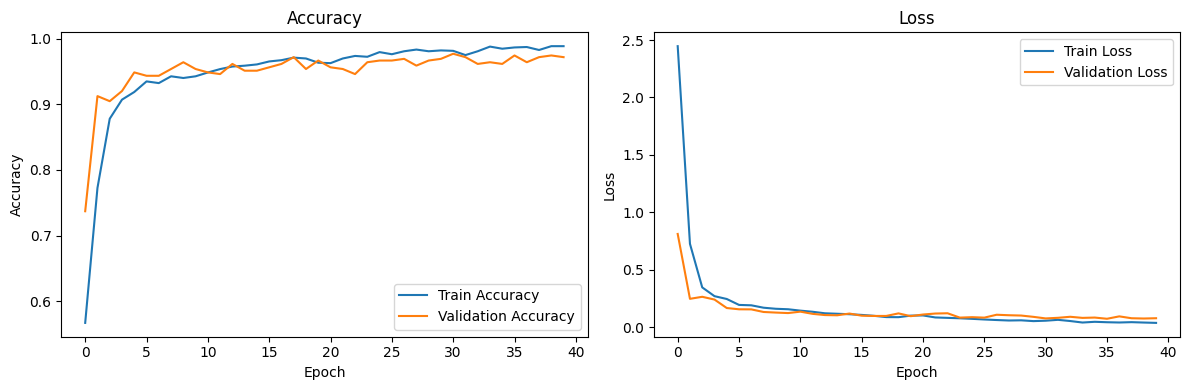

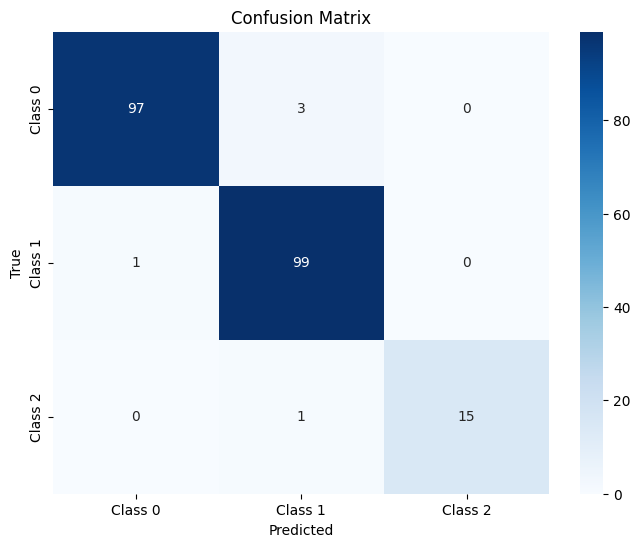

In [5]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, accuracy_score, f1_score, recall_score, precision_score, confusion_matrix
from sklearn.preprocessing import label_binarize
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

# Load the history
history_path = './models/training_history_densnet.pkl'
with open(history_path, 'rb') as f:
    history = pickle.load(f)

# Extract metrics from the history
train_accuracy = history['accuracy']
val_accuracy = history['val_accuracy']
train_loss = history['loss']
val_loss = history['val_loss']

# Load the saved model
model_path = "./models/densenet_model.h5"
model = tf.keras.models.load_model(model_path)

# Load the testing dataset
testing_dir = "./testing"
test_fold_ds = tf.keras.utils.image_dataset_from_directory(
    testing_dir,
    image_size=(224, 224),
    batch_size=100
)

# Function to calculate Dice coefficient
def dice_coefficient(y_true, y_pred):
    y_true_f = np.asarray(y_true).flatten()
    y_pred_f = np.asarray(y_pred).flatten()
    intersection = np.sum(y_true_f * y_pred_f)
    return (2. * intersection) / (np.sum(y_true_f) + np.sum(y_pred_f))

# Calculate predictions and true labels
true_labels = []
predicted_labels = []

for images, labels in test_fold_ds:
    true_labels.extend(labels.numpy())
    predictions = model.predict(images)
    predicted_labels.extend(np.argmax(predictions, axis=1))

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# Binarize the labels for calculating the Dice coefficient
true_labels_bin = label_binarize(true_labels, classes=[0, 1, 2])
predicted_labels_bin = label_binarize(predicted_labels, classes=[0, 1, 2])

# Calculate metrics
accuracy = accuracy_score(true_labels, predicted_labels)
f1 = f1_score(true_labels, predicted_labels, average='macro')
recall = recall_score(true_labels, predicted_labels, average='macro')
precision = precision_score(true_labels, predicted_labels, average='macro')
dice = dice_coefficient(true_labels_bin, predicted_labels_bin)
conf_matrix = confusion_matrix(true_labels, predicted_labels)

# Print metrics
print(f"Final Training Accuracy: {train_accuracy[-1] * 100:.2f}%")
print(f"Final Validation Accuracy: {val_accuracy[-1] * 100:.2f}%")
print(f"Final Training Loss: {train_loss[-1]:.4f}")
print(f"Final Validation Loss: {val_loss[-1]:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"F1 Score: {f1:.4f}")
print(f"Recall: {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Dice Coefficient: {dice:.4f}")

# Plot Accuracy and Loss Graphs
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(train_accuracy, label='Train Accuracy')
plt.plot(val_accuracy, label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(train_loss, label='Train Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=[f"Class {i}" for i in range(3)], yticklabels=[f"Class {i}" for i in range(3)])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
